# Week 6 (Tree-based Models)

## 2.1. Decision Tree

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [2]:
# 데이터 로드 및 전처리
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 훈련/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Q1.1 max_depth 파라미터를 변경하면 트리의 구조와 성능이 어떻게 변할까요?

In [3]:
# 결정 트리 모델 생성 및 학습
tree_model = DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=2, random_state=42)
tree_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, random_state=42)

In [4]:
for depth in [1, 3, 5, 10, None]:
    model = DecisionTreeClassifier(criterion="gini", max_depth=depth, min_samples_leaf=2, random_state=42)
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    print(f"max_depth={depth}: train={train_acc:.3f}, test={test_acc:.3f}")

max_depth=1: train=0.675, test=0.633
max_depth=3: train=0.950, test=1.000
max_depth=5: train=0.975, test=1.000
max_depth=10: train=0.975, test=1.000
max_depth=None: train=0.975, test=1.000


### Q1.2 'gini'와 'entropy' 기준의 차이는 무엇이며, 결과에 어떤 영향을 미칠까요?

In [ ]:
공통점: 트리가 노드를 분할할 때 분순한지를 측정하는 기준
차이점: gini:제곱 연산만 사용하여 무작위로 하나뽑았을때 잘못 분류될 확률,계산이 더 빠름
        entropy:정보이론 기반, 로그 연산 사용해서 불확실성/정보량을 측정

### Q1.3 각 노드의 분할 기준 어떻게 되는지

---

설명해보세요.

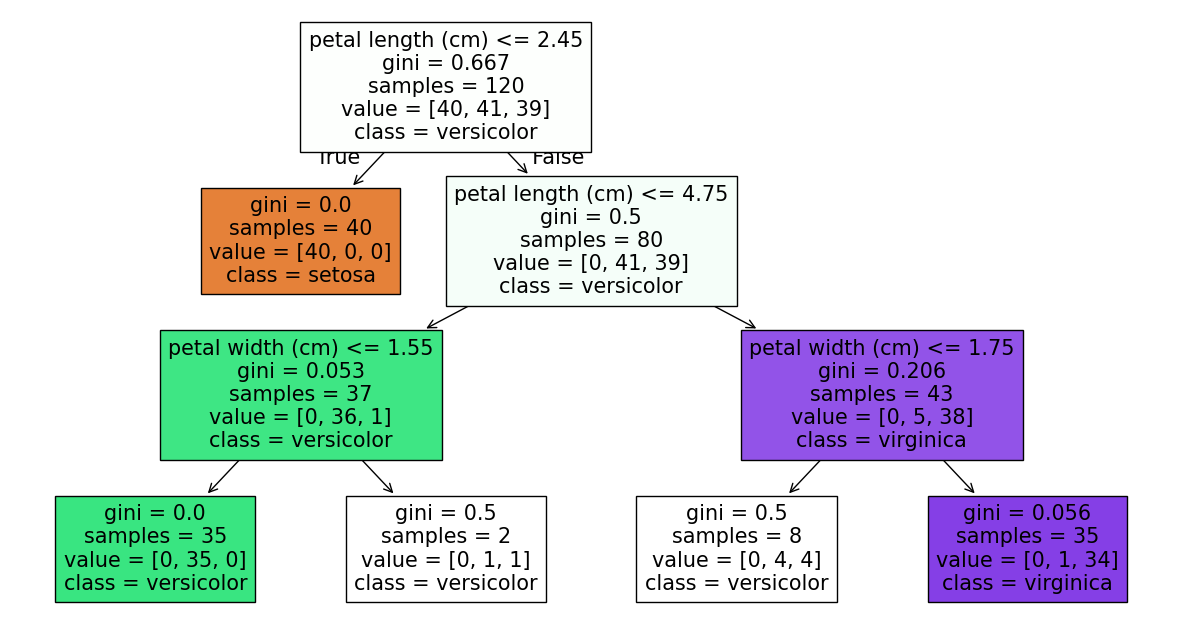

In [5]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(tree_model, feature_names=X_train.columns, class_names=['setosa','versicolor','virginica'], filled=True)
plt.show()

트리는 매 노드마다 gini 불순도를 가장 많이 줄이는 feature와 임계값을 골라 분할한다. Root에서는 petal length ≤ 2.45로 setosa를 완벽히 분리했고(gini=0), 나머지 두 클래스(versicolor/virginica)는 이후 petal length ≤ 4.75, petal width ≤ 1.55/1.75 기준으로 순차적으로 나뉘며 점점 순수한 노드(gini가 0에 가까움)로 좁혀졌다. 즉 petal length가 1차 구분자, petal width가 2차 구분자 역할을 함.

In [7]:
# 트리 시각화 (Graphviz)
dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

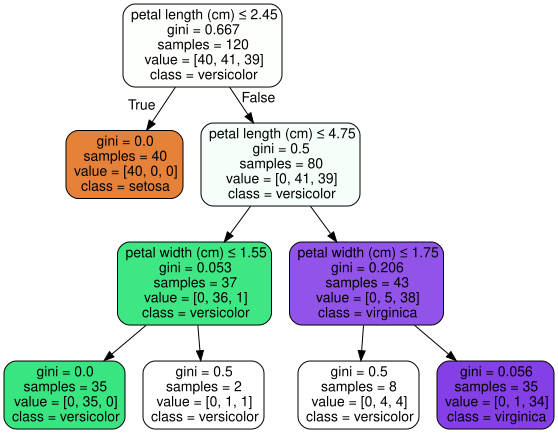

In [8]:
# 그래프 출력
graph = graphviz.Source(dot_data)
graph

## 3. 앙상블 학습: 부스팅(Boosting) 모델

Adaboost, Gradient Boosting Model은 scikit learn에서 지원하지만, LightGBM과 XGBoost의 경우는 외부 패키지를 불러와야 합니다.

Boosting 계열의 모델들은 데이터 개수가 적으면 overfitting이 일어나는 경우가 많으니, 주의해야 합니다.

In [10]:
# 필요한 패키지 로드
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error

housing = fetch_california_housing()

In [11]:
# 데이터 로드
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['MedHouseVal'] = housing.target

In [12]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Q3.1 `housing_df`를 train, test split을 해봅시다.

분할 비율을 자유롭게 설정해봅시다.

In [14]:
# 데이터 분할
X = housing_df.drop(columns=['MedHouseVal'])
y = housing_df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2 , random_state=42)

### Q3.2  데이터를 `RandomForestRegressor`에 적합해 봅시다.
train set 에 대해 `MedHouseVal`을 종속변수, 나머지를 독립변수로 하는 random forest regressor를 적합해 봅시다.

test set으로 prediction을 한 후 MSE를 구해 봅시다.

In [15]:
from sklearn.ensemble import RandomForestRegressor

In [16]:
# 모델 생성 및 학습
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# test set 예측
y_pred = rf_model.predict(X_test)

# MSE 계산
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")

Test MSE: 0.2554


### Q3.3 데이터를 `AdaBoostRegressor`에 적합해봅시다.

위와 동일

In [18]:
from sklearn.ensemble import AdaBoostRegressor

In [19]:
ada_model = AdaBoostRegressor(random_state=42)
ada_model.fit(X_train, y_train)
y_pred = ada_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"AdaBoost Test MSE: {mse:.4f}")

AdaBoost Test MSE: 0.6145


### Q3.4 데이터를 `GradientBoostingRegressor`에 적합해 봅시다.

위와 동일

In [20]:
from sklearn.ensemble import GradientBoostingRegressor

In [21]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"GradientBoosting Test MSE: {mse:.4f}")

GradientBoosting Test MSE: 0.2940


### Q3.5 데이터를 `lightgbm` 회귀에 적합해 봅시다.

파라미터를 자세히 살펴보고, 자유롭게 설정해 봅시다.

Documentation
https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

예시
https://www.geeksforgeeks.org/regression-using-lightgbm/


In [22]:
import lightgbm as lgb

In [24]:
lgbm_model = lgb.LGBMRegressor(random_state=42)
lgbm_model.fit(X_train, y_train)
y_pred = lgbm_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"LightGBM Test MSE: {mse:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004700 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
LightGBM Test MSE: 0.2148


### Q3.6 데이터를 `xgboost`에 적합해 봅시다.

파라미터는 자유롭게 설정해 봅시다

In [27]:
import xgboost as xgb


In [28]:
xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"XGBoost Test MSE: {mse:.4f}")

XGBoost Test MSE: 0.2140


### Q3.7 `RandomForestRegressor`의 feature importance를 시각화해봅시다.

https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

위를 참고해보면서 Q2에서 적합한 random forest regressor의 feature importance를 시각화해 봅시다.

중요한 feature 부터 내림차순으로 시각화해 봅시다.

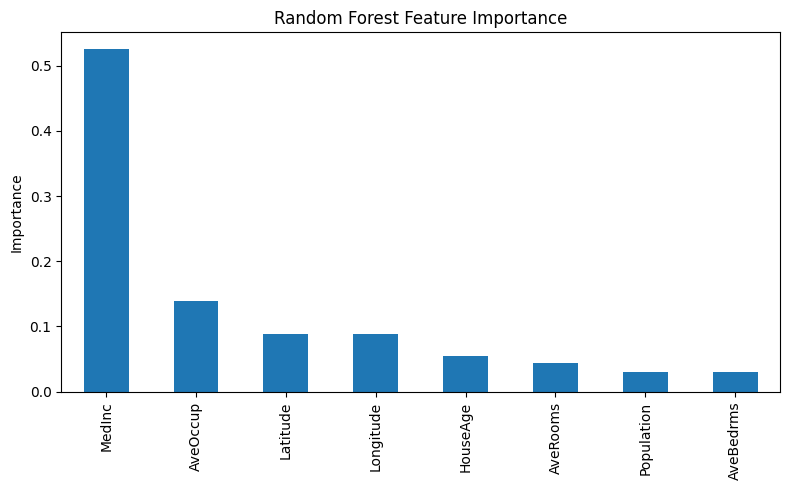

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

importances = rf_model.feature_importances_
feat_names = X_train.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.plot(kind='bar')
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### (BONUS) 1. Boosting 모델 각각의 특징을 정리해보세요.

AdaBoost: 이전 모델이 틀린 샘플에 가중치를 높여서 다음 모델이 그 샘플에 더 집중하게 만드는 방식. 구조 단순하고 빠르지만, 이상치(outlier)에 민감함
GradientBoosting: 이전 모델의 잔차(residual, 오차)를 예측하는 새 모델을 계속 추가해가는 방식. AdaBoost보다 유연하고 성능 좋지만, 학습 느리고 하이퍼파라미터 튜닝 민감함
XGBoost: GradientBoosting에 정규화(regularization) 추가해서 overfitting 방지, 병렬처리로 속도 개선한 버전. 캐글 등 대회에서 많이 쓰임
LightGBM: XGBoost보다 더 빠르게 만든 버전. leaf-wise 방식으로 트리를 키워서(다른 건 level-wise) 대용량 데이터에서 특히 빠르고 메모리 효율적. 다만 데이터 적으면 overfitting 위험 좀 더 있음

### (BONUS) 2. 모델 성능을 높이기 위하여 어떤 시도를 하면 좋을지 고민해보세요.

하이퍼파라미터 튜닝: GridSearchCV로 RandomizedSearchCV로 n_estimators, max_depth, learning_rate 등 최적화
feature engineering: 기존 feature 조합해서 새 feature 생성 (예: 위도/경도로 지역 클러스터링), 또는 불필요한 feature 제거
스케일링: 트리 기반 모델은 스케일링 영향 적지만, 선형모델 앙상블이면 도움될 수 있음
앙상블/스태킹: 여러 모델(RF+XGB+LGBM) 예측값을 평균내거나 스태킹해서 성능 개선
outlier 처리: MedHouseVal이나 feature에 극단값 있으면 처리해보기
cross-validation: 지금은 train/test 한 번만 나눴는데, k-fold CV로 더 안정적인 성능 평가